# Amazon Product Review Sentiment Analysis

## Project Overview
The goal of this project is to build a machine learning model capable of classifying the sentiment of Amazon product reviews. 
We utilize classical NLP techniques (TF-IDF) and machine learning algorithms (Random Forest, SVM) to predict whether a customer review is positive or negative.

## Workflow
1. **Data Loading & Cleaning**: Handling duplicates and missing values.
2. **Preprocessing**: Text normalization, lemmatization, and stopword removal.
3. **Feature Extraction**: Converting text to numerical vectors using TF-IDF.
4. **Model Training**: Comparing Random Forest and Support Vector Machine (SVM).
5. **Evaluation**: Assessing performance using Accuracy and ROC-AUC scores.

In [1]:
# 1. Import Libraries & Setup

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from textblob import Word, TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_validate, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, auc, roc_curve, classification_report, confusion_matrix


# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Download necessary NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

In [2]:
os.makedirs("../images", exist_ok=True)

## 2. Data Loading and Cleaning

In [3]:
# Load the dataset
df = pd.read_csv("../data/amazon_reviews.csv")

# Display initial shape
print(f"Initial dataset shape: {df.shape}")

# --- Data Cleaning Steps ---

# 1. Remove Duplicates
initial_count = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_count - len(df)} duplicate rows.")

# 2. Handle Missing Values in Text
df = df.dropna(subset=['reviewText'])

# 3. Remove Empty Strings (Whitespace only)
empty_string_mask = df['reviewText'].astype(str).str.strip() == ""
df = df[~empty_string_mask]

print(f"Final dataset shape after cleaning: {df.shape}")
df.head()

Initial dataset shape: (4915, 12)
Removed 0 duplicate rows.
Final dataset shape after cleaning: (4914, 12)


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",No issues.,4.0,Four Stars,1406073600,2014-07-23,138,0,0
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]","Purchased this for my device, it worked as adv...",5.0,MOAR SPACE!!!,1382659200,2013-10-25,409,0,0
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",it works as expected. I should have sprung for...,4.0,nothing to really say....,1356220800,2012-12-23,715,0,0
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",This think has worked out great.Had a diff. br...,5.0,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382,0,0
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]","Bought it with Retail Packaging, arrived legit...",5.0,best deal around,1373673600,2013-07-13,513,0,0


## 3. Feature Engineering: Creating Sentiment Labels
Instead of using pre-built sentiment tools (like VADER), we will derive the "ground truth" sentiment directly from the customer's Star Rating.
* **Positive:** 4 or 5 stars
* **Negative:** 1 or 2 stars
* **Neutral:** 3 stars (We will exclude these to sharpen the model)

In [4]:
# Create labels based on Star Rating
df = df[df["overall"].notna()].copy()

df["sentiment_label"] = df["overall"].apply(
    lambda r: "pos" if r >= 4 else ("neg" if r <= 2 else "neu")
)

# Drop Neutral reviews (3 stars) for binary classification
df = df[df["sentiment_label"] != "neu"].copy()

# Encode labels: pos -> 1, neg -> 0
le = LabelEncoder()
df["target"] = le.fit_transform(df["sentiment_label"])

# Check class distribution
print("Class Distribution:")
print(df["sentiment_label"].value_counts())

Class Distribution:
pos    4448
neg     324
Name: sentiment_label, dtype: int64


## 4. Text Preprocessing
We apply standard NLP preprocessing steps:
1.  **Lowercasing**: Uniformity.
2.  **Removing Punctuation & Numbers**: Noise reduction.
3.  **Stopword Removal**: Removing common words (the, is, and).
4.  **Lemmatization**: Reducing words to their root form (e.g., "running" -> "run").

In [5]:
# Define Stopwords
sw = stopwords.words('english')

def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove Punctuation and Numbers
    text = text.replace("\d+", "")
    text = text.replace("[^\w\s]", "")
    # 3. Remove Stopwords
    text = " ".join([word for word in text.split() if word not in sw])
    # 4. Lemmatization (Optional but recommended)
    text = " ".join([Word(word).lemmatize() for word in text.split()])
    return text

# Apply preprocessing
df['cleaned_text'] = df['reviewText'].apply(preprocess_text)

# Preview
df[['reviewText', 'cleaned_text']].head()

,reviewText,cleaned_text
0,No issues.,issues.
1,"Purchased this for my device, it worked as adv...","purchased device, worked advertised. never muc..."
2,it works as expected. I should have sprung for...,work expected. sprung higher capacity. think m...
3,This think has worked out great.Had a diff. br...,think worked great.had diff. bran 64gb card we...
4,"Bought it with Retail Packaging, arrived legit...","bought retail packaging, arrived legit, orange..."


## 5. TF-IDF Vectorization
We convert the cleaned text into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency), which highlights words that are important to a specific document but rare across the corpus.

In [6]:
X = df['cleaned_text']
y = df['target']

# Initialize TF-IDF
tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(X)

print(f"Feature Matrix Shape: {X_tfidf.shape}")

Feature Matrix Shape: (4772, 2000)


## 6. Visualizing Sentiment Distribution
A quick look at the polarity of the dataset.

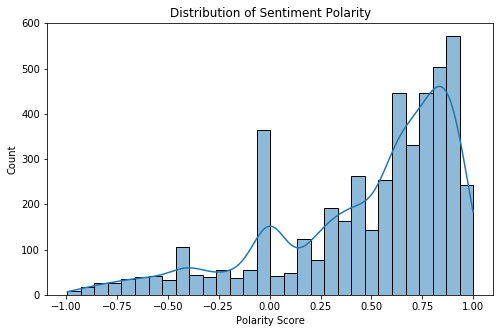

In [7]:
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Calculate polarity just for visualization
df['polarity'] = df['cleaned_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

plt.figure(figsize=(8,5))
try:
    sns.histplot(df['polarity'], bins=30, kde=True)
except AttributeError:
    # Fallback for older seaborn versions
    sns.distplot(df['polarity'], bins=30, kde=True)

plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Polarity Score')
plt.show()

## 7. Model Training & Evaluation
We use a **Train/Test Split** for immediate accuracy scores, followed by **Cross-Validation** to ensure robust performance metrics.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

print("--- 1. Random Forest ---")
# Added class_weight='balanced' to handle the imbalanced positive/negative reviews
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Step A: Train on split data
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest Test Set Accuracy: {rf_acc:.3f}")

# Step B: Cross-Validation
print("Running Cross-Validation...")
rf_cv = cross_validate(rf, X_tfidf, y, cv=5, scoring=['accuracy', 'roc_auc'])
print(f"Random Forest CV Mean Accuracy:  {rf_cv['test_accuracy'].mean():.3f}")
print(f"Random Forest CV Mean ROC-AUC:   {rf_cv['test_roc_auc'].mean():.3f}")


print("\n--- 2. Support Vector Machine  ---")
# Added class_weight='balanced'
svc = SVC(kernel='linear', probability=True, random_state=42, class_weight='balanced')

# Step A: Train on split data
svc.fit(X_train, y_train)
svc_acc = accuracy_score(y_test, svc.predict(X_test))
print(f"SVM Test Set Accuracy: {svc_acc:.3f}")

# Step B: Cross-Validation
print("Running Cross-Validation...")
svc_cv = cross_validate(svc, X_tfidf, y, cv=5, scoring=['accuracy', 'roc_auc'])
print(f"SVM CV Mean Accuracy:  {svc_cv['test_accuracy'].mean():.3f}")
print(f"SVM CV Mean ROC-AUC:   {svc_cv['test_roc_auc'].mean():.3f}")

--- 1. Random Forest ---
Random Forest Test Set Accuracy: 0.936
Running Cross-Validation...
Random Forest CV Mean Accuracy:  0.939
Random Forest CV Mean ROC-AUC:   0.949

--- 2. Support Vector Machine  ---
SVM Test Set Accuracy: 0.960
Running Cross-Validation...
SVM CV Mean Accuracy:  0.953
SVM CV Mean ROC-AUC:   0.957


## 8. Confusion Matrix 
Shows prediction errors. SVM handles both classes better than Random Forest.

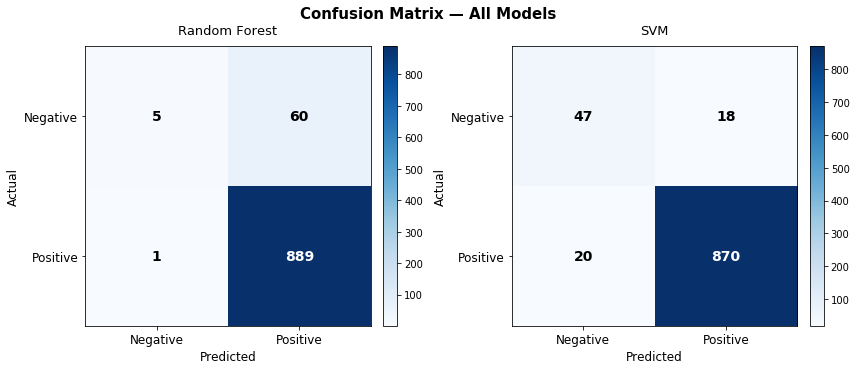

In [9]:
def plot_confusion_matrix(models, X_test, y_test):
    n = len(models)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    fig.patch.set_facecolor('white')
    if n == 1:
        axes = [axes]

    for ax, (name, model) in zip(axes, models.items()):
        cm = confusion_matrix(y_test, model.predict(X_test))
        thresh = cm.max() / 2
        ax.set_facecolor('white')
        im = ax.imshow(cm, interpolation='nearest', cmap='Blues', aspect='auto')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        for i in range(2):
            for j in range(2):
                ax.annotate(str(cm[i, j]), xy=(j, i),
                            ha='center', va='center', fontsize=14, fontweight='bold',
                            color='white' if cm[i, j] > thresh else 'black')

        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(['Negative', 'Positive'], fontsize=12)
        ax.set_yticklabels(['Negative', 'Positive'], fontsize=12)
        ax.tick_params(top=False, bottom=True, labeltop=False, labelbottom=True)
        ax.set_xlim(-0.5, 1.5); ax.set_ylim(1.5, -0.5)
        ax.set_xlabel('Predicted', fontsize=12)
        ax.set_ylabel('Actual', fontsize=12)
        ax.set_title(name, fontsize=13, pad=12)

    plt.suptitle('Confusion Matrix — All Models', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../images/confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

# Plot confusion matrices for both models
models = {'Random Forest': rf, 'SVM': svc}
plot_confusion_matrix(models, X_test, y_test)

## 9. Classification Reports
Provides precision, recall, and F1-score. SVM achieves better balance across classes.

In [10]:
accuracy_data = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy_data[name] = accuracy_score(y_test,y_pred)

accuracy_df = pd.DataFrame(
    accuracy_data.items(),
    columns=['Model', 'Accuracy']
)

accuracy_df['Accuracy'] = accuracy_df['Accuracy'].apply(lambda x: f'{x:.2%}')
print(accuracy_df)

           Model Accuracy
0  Random Forest   93.61%
1            SVM   96.02%


In [11]:


def comparison_classification_reports(models, X_test, y_test):

    comparison_data = []


    for name, model in models.items():

        y_pred = model.predict(X_test)
        report = classification_report(y_test, y_pred, output_dict=True)
        comparison_data.append({
            "Model": name,
            "Accuracy": report['accuracy'],
            "Precision (0)": report['0']['precision'],
            "Recall (0)": report['0']['recall'],
            "F1-Score (0)": report['0']['f1-score'],
            "Precision (1)": report['1']['precision'],
            "Recall (1)": report['1']['recall'],
            "F1-Score (1)": report['1']['f1-score']
            })

    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.set_index('Model')
    comparison_df.index.name = None

    numeric_cols = [
        "Accuracy",
        "Precision (0)",
        "Recall (0)",
        "F1-Score (0)",
        "Precision (1)",
        "Recall (1)",
        "F1-Score (1)"
        ]

    styled_comparison_df = (comparison_df[numeric_cols].style
                            .format({col:"{:.2%}" for col in numeric_cols})
                            .set_caption("Comparison of Classification Reports")
                            .set_table_styles([{
                                'selector': 'caption',
                                'props': [
                                    ('font-size', '16px'),
                                    ('font-weight', 'bold'),
                                    ('color', '#2c3e50'),
                                    ('padding', '12px'),
                                    ('text-align', 'center')
                                        ]
                            },
                            {
                                'selector': 'th',
                                'props': [
                                    ('background-color', '#2c3e50'),
                                    ('font-weight', 'bold'),
                                    ('color', 'white'),
                                    ('padding', '10px 14px'),
                                    ('text-align', 'center')
                                ]
                            },
                            {
                                'selector' : 'th.row_heading',
                                'props': [
                                    ('background-color', '#2e3e50'),
                                    ('font-weight', 'bold'),
                                    ('text-align', 'center'),
                                    ('color', 'white'),
                                    ('padding', '10px 14px')
                                ]
                            },
                            {
                                'selector' : 'td',
                                'props': [
                                    ('color', "#546F8D"),
                                    ('padding', '10px 14px'),
                                    ('text-align', 'center'),
                                    ('font-size', '16px'),
                                    ('border', '1px solid #ddd')
                                ]
                            },
                            {
                                'selector': 'tr:nth-child(even)',
                                'props': [('background-color', '#f9f9f9')
                                ]
                             },
                             {
                                 'selector': 'tr:hover',
                                 'props': [('background-color', '#eaf4fb')]}
                            ]))


    display(styled_comparison_df)

In [12]:
comparison_classification_reports(models, X_test, y_test)

,Accuracy,Precision (0),Recall (0),F1-Score (0),Precision (1),Recall (1),F1-Score (1)
Random Forest,93.61%,83.33%,7.69%,14.08%,93.68%,99.89%,96.68%
SVM,96.02%,70.15%,72.31%,71.21%,97.97%,97.75%,97.86%


## 10. ROC Curve
ROC curve shows model discrimination ability. SVM performs better with higher AUC.

In [13]:
y_pred_proba = rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
roc_auc

0.9435955056179776

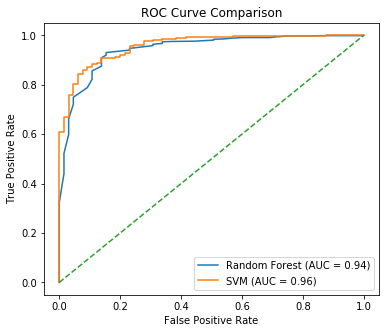

In [14]:
plt.figure(figsize=(6,5))

for name, model in models.items():
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.savefig("../images/roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

In this project, a sentiment analysis pipeline was developed to classify Amazon
customer reviews as positive or negative using classical NLP techniques.

**Key Findings:**
- **Data Preparation:** Removing duplicate entries and neutral reviews improved
  label consistency and model reliability.
- **Model Performance:** The **Linear SVM** achieved the best overall performance,
  with an accuracy of approximately **96%** and a **ROC-AUC of 0.96**, outperforming
  tree-based models such as Random Forest.
- **Business Relevance:** The model demonstrates potential for automating the
  categorization of customer feedback, enabling faster identification and
  prioritization of negative reviews.

**Future Improvements:**
- Explore deep learning approaches (e.g., LSTM, BERT) to better capture contextual
  and semantic information.
- Deploy the trained model via a lightweight REST API (e.g., Flask or FastAPI).